<a href="https://colab.research.google.com/github/JungYeoni/study_torch/blob/main/ML/Softmax%20Regression/%EC%86%8C%ED%94%84%ED%8A%B8%EB%A7%A5%EC%8A%A4_%ED%9A%8C%EA%B7%80%EB%A1%9C_MNIST_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EB%B6%84%EB%A5%98%ED%95%98%EA%B8%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 소프트맥스 회귀로 MNIST 데이터 분류하기

학습 자료
> https://wikidocs.net/60324

## 데이터 이해하기
- 0부터 9까지의 이미지로 구성된 손글씨 데이터셋
- 과거 우체국에서 편지의 우편 번호를 인식하기 위해서 만들어진 훈련 데이터
- 60,000개의 훈련 데이터와 레이블, 10,000개의 테스트 데이터와 레이블로 구성
- 레이블은 0부터 9까지 총 10개
- 머신러닝을 배울 때 접하게 되는 가장 기본적인 예제

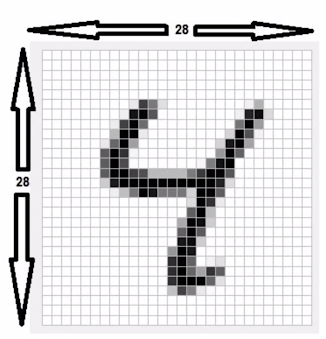

```python
# 28 x 28 = 784 차원의 벡터로 만드는 코드
for X, Y in data_loader:
  #  입력 이미지를 [batch_size x 784]의 크기로 reshape
  X = X.view(-1, 28*28)
```

## 토치비전(torchvision) 소개하기

- 이미 구현되어져 있는 유명한 모델들, 일반적인 이미지 전처리 도구들을 포함하고 있는 패키지

## 분류기 구현을 위한 사전 설정

In [1]:
import torch
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
import random

In [2]:
USE_CUDA = torch.cuda.is_available()
device = torch.device("cuda" if USE_CUDA else "cpu")
print('다음 기기로 학습합니다:', device)

다음 기기로 학습합니다: cuda


In [3]:
# 랜덤시드 고정
random.seed(777)
torch.manual_seed(777)

if device == 'cuda':
  torch.cuda.manual_seed_all(777)

In [4]:
# hyperparameters
training_epochs = 15
batch_size = 100

## MNIST 분류기 구현하기

In [6]:
# MNIST 데이터셋 불러오기
mnist_train = dsets.MNIST(root='MNIST_data', # 데이터를 다운로드 받을 경로
                          train=True,
                          transform=transforms.ToTensor(), # 현재 데이터를  파이토치 텐서로 변환
                          download=True)
mnist_test = dsets.MNIST(root='MNIST_data',
                         train=False,
                         transform=transforms.ToTensor(),
                         download=True)

In [8]:
from torchvision.datasets.folder import DatasetFolder
# dataset loader
data_loader = DataLoader(dataset=mnist_train,
                         batch_size=batch_size,
                         shuffle=True,
                         drop_last=True) # 마지막 배치를 버리려면 drop_last=True

In [9]:
# 모델 설계
linear = nn.Linear(784, 10, bias=True).to(device) # to(): 어디서 연산을 수행할지

In [11]:
# 비용 함수와 옵티마이저 정의
criterion = nn.CrossEntropyLoss().to(device) # 내부적으로 소프트맥스 함수 포함
optimizer = torch.optim.SGD(linear.parameters(), lr=0.01)

In [14]:
for epoch in range(training_epochs):
  avg_cost = 0
  total_batch = len(data_loader)

  for X, Y in data_loader:
    X = X.view(-1, 28 * 28).to(device)
    Y = Y.to(device)

    optimizer.zero_grad()
    hypothesis = linear(X) # 모델의 순전파 과정을 수행하여 예측값 계산
    cost = criterion(hypothesis, Y)
    cost.backward()
    optimizer.step()

    avg_cost += cost / total_batch

  print('Epoch:', '%04d' % (epoch + 1), 'cost =', '{:.9f}'.format(avg_cost))

print('Learning finished')

Epoch: 0001 cost = 0.742240131
Epoch: 0002 cost = 0.571436346
Epoch: 0003 cost = 0.504205704
Epoch: 0004 cost = 0.466202974
Epoch: 0005 cost = 0.440810084
Epoch: 0006 cost = 0.422610372
Epoch: 0007 cost = 0.408429950
Epoch: 0008 cost = 0.397262901
Epoch: 0009 cost = 0.388054848
Epoch: 0010 cost = 0.380166411
Epoch: 0011 cost = 0.373511672
Epoch: 0012 cost = 0.367690086
Epoch: 0013 cost = 0.362563550
Epoch: 0014 cost = 0.357978940
Epoch: 0015 cost = 0.353816986
Learning finished


- `total_batch`: 에포크 당 수행할 배치 수 계산
- `data_loader`: 미니배치 학습을 위해 반복적으로 데이터를 제공하는 역할

- 루프 내부에서는 각 배치마다 입력 데이터 X와 레이블 Y를 받아옴 -> 이 때 이미지 데이터로서 (100, 784) 크기의 텐서로 변환됨
- 이는 배치 크기 100에 28x28 픽셀의 데이터가 일렬로 펼쳐진 상태를 나타냄

- 이 데이터와 레이블 Y는 모델 학습을 위해 지정된 장치(device)로 전송됨

Accuracy: 0.9035999774932861
Lable:  7
Prediction:  7


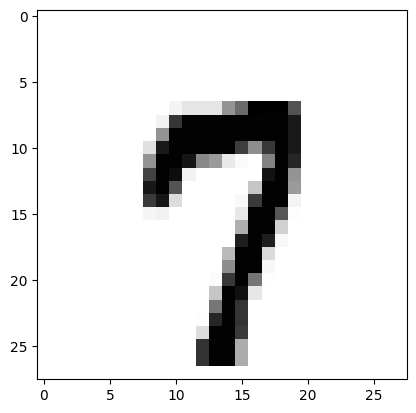

In [17]:
# 테스트 데이터로 평가하기
with torch.no_grad(): # gradient 계산을 수행하지 않는다.
  X_test = mnist_test.test_data.view(-1, 28 * 28).float().to(device)
  Y_test = mnist_test.test_labels.to(device)

  prediction = linear(X_test)
  correct_prediction = torch.argmax(prediction, 1) == Y_test
  accuracy = correct_prediction.float().mean()
  print('Accuracy:', accuracy.item())

  # MNIST 테스트 데이터에서 무작위로 하나를 뽑아서 예측
  r = random.randint(0, len(mnist_test) - 1)
  X_single_data = mnist_test.test_data[r:r+1].view(-1, 28 * 28).float().to(device)
  Y_single_data = mnist_test.test_labels[r:r+1].to(device)

  print('Lable: ', Y_single_data.item())
  single_prediction = linear(X_single_data)
  print('Prediction: ', torch.argmax(single_prediction, 1).item())

  plt.imshow(mnist_test.test_data[r:r+1].view(28, 28), cmap='Greys', interpolation='nearest')
  plt.show()